In [2]:
!pip install kaggle tqdm matplotlib

import os
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.models as models

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [3]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"soumojaykarmakar","key":"b2ac274459ff645ba55d3fe7d026fa8a"}'}

In [4]:
import os
import shutil

os.makedirs("/root/.kaggle", exist_ok=True)
shutil.move("kaggle.json", "/root/.kaggle/kaggle.json")
os.chmod("/root/.kaggle/kaggle.json", 600)

In [5]:
!kaggle datasets download -d andrewmvd/pothole-detection -p ./data --quiet

Dataset URL: https://www.kaggle.com/datasets/andrewmvd/pothole-detection
License(s): other


In [6]:
import zipfile

with zipfile.ZipFile("./data/pothole-detection.zip", 'r') as zip_ref:
    zip_ref.extractall("./data")

print("Dataset extracted!")

Dataset extracted!


In [32]:
img_dir = "./data/images"
annotation_file = "./data/annotations.csv"

In [34]:
import os

for root, dirs, files in os.walk("./data"):
    print(root)
    for f in files[:5]:
        print("  ", f)

./data
   pothole-detection.zip
./data/annotations
   potholes248.xml
   potholes215.xml
   potholes330.xml
   potholes545.xml
   potholes94.xml
./data/images
   potholes661.png
   potholes305.png
   potholes591.png
   potholes458.png
   potholes514.png


In [57]:
import xml.etree.ElementTree as ET
import pandas as pd
import os

def parse_all_xml(annotation_dir):
    data = []

    for file in os.listdir(annotation_dir):
        if not file.endswith(".xml"):
            continue

        xml_path = os.path.join(annotation_dir, file)
        tree = ET.parse(xml_path)
        root = tree.getroot()

        # filename inside XML
        filename = root.find("filename").text
        filename = filename.replace(".jpg", ".png")

        for obj in root.findall("object"):
            bbox = obj.find("bndbox")

            xmin = int(bbox.find("xmin").text)
            ymin = int(bbox.find("ymin").text)
            xmax = int(bbox.find("xmax").text)
            ymax = int(bbox.find("ymax").text)

            data.append({
                "filename": filename,
                "xmin": xmin,
                "ymin": ymin,
                "xmax": xmax,
                "ymax": ymax
            })

    return pd.DataFrame(data)

In [54]:
!ls ./data

annotations  images  pothole-detection.zip


In [55]:
!ls ./data/*

./data/pothole-detection.zip

./data/annotations:
potholes0.xml	 potholes250.xml  potholes400.xml  potholes551.xml
potholes100.xml  potholes251.xml  potholes401.xml  potholes552.xml
potholes101.xml  potholes252.xml  potholes402.xml  potholes553.xml
potholes102.xml  potholes253.xml  potholes403.xml  potholes554.xml
potholes103.xml  potholes254.xml  potholes404.xml  potholes555.xml
potholes104.xml  potholes255.xml  potholes405.xml  potholes556.xml
potholes105.xml  potholes256.xml  potholes406.xml  potholes557.xml
potholes106.xml  potholes257.xml  potholes407.xml  potholes558.xml
potholes107.xml  potholes258.xml  potholes408.xml  potholes559.xml
potholes108.xml  potholes259.xml  potholes409.xml  potholes55.xml
potholes109.xml  potholes25.xml   potholes40.xml   potholes560.xml
potholes10.xml	 potholes260.xml  potholes410.xml  potholes561.xml
potholes110.xml  potholes261.xml  potholes411.xml  potholes562.xml
potholes111.xml  potholes262.xml  potholes412.xml  potholes563.xml
potholes112.xml 

In [58]:
train_dataset = PotholeDataset(
    img_dir="./data/images",
    annotation_file="./data/annotations"
)

In [59]:
train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True
)

In [49]:
class PotholeDataset(Dataset):
    def __init__(self, img_dir, annotation_file, image_size=(256,256)):
        self.img_dir = img_dir
        self.df = parse_all_xml(annotation_file)
        self.image_size = image_size

        self.image_names = self.df['filename'].unique()

        self.transform = transforms.Compose([
            transforms.Resize(image_size),
            transforms.ToTensor(),
            transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
        ])

    def __len__(self):
        return len(self.image_names)

    def __getitem__(self, idx):
        img_name = self.image_names[idx]
        img_path = os.path.join(self.img_dir, img_name)

        image = Image.open(img_path).convert("RGB")

        orig_w, orig_h = image.size
        image = self.transform(image)

        mask = np.zeros((self.image_size[1], self.image_size[0]), dtype=np.uint8)

        rows = self.df[self.df['filename'] == img_name]

        for _, row in rows.iterrows():
            x1, y1, x2, y2 = row['xmin'], row['ymin'], row['xmax'], row['ymax']

            x1 = int(x1 * self.image_size[0] / orig_w)
            x2 = int(x2 * self.image_size[0] / orig_w)
            y1 = int(y1 * self.image_size[1] / orig_h)
            y2 = int(y2 * self.image_size[1] / orig_h)

            mask[y1:y2, x1:x2] = 1

        mask = torch.tensor(mask, dtype=torch.long)

        return image, mask

In [60]:
import torchvision.models as models
import torch.nn as nn

class VGG16_Backbone(nn.Module):
    def __init__(self, pretrained=True):
        super(VGG16_Backbone, self).__init__()

        vgg = models.vgg16(pretrained=pretrained).features

        # Split into stages (important for hypercolumns)
        self.stage1 = vgg[:5]    # conv1
        self.stage2 = vgg[5:10]  # conv2
        self.stage3 = vgg[10:17] # conv3
        self.stage4 = vgg[17:24] # conv4
        self.stage5 = vgg[24:31] # conv5

    def forward(self, x):
        f1 = self.stage1(x)
        f2 = self.stage2(f1)
        f3 = self.stage3(f2)
        f4 = self.stage4(f3)
        f5 = self.stage5(f4)

        return [f1, f2, f3, f4, f5]

In [61]:
backbone = VGG16_Backbone().to(device)

x = torch.randn(1, 3, 256, 256).to(device)
features = backbone(x)

for i, f in enumerate(features):
    print(f"Feature {i+1} shape:", f.shape)

Feature 1 shape: torch.Size([1, 64, 128, 128])
Feature 2 shape: torch.Size([1, 128, 64, 64])
Feature 3 shape: torch.Size([1, 256, 32, 32])
Feature 4 shape: torch.Size([1, 512, 16, 16])
Feature 5 shape: torch.Size([1, 512, 8, 8])


In [62]:
import torch.nn.functional as F

class Hypercolumn(nn.Module):
    def __init__(self):
        super(Hypercolumn, self).__init__()

    def forward(self, features):
        target_size = features[0].shape[2:]

        upsampled = []
        for f in features:
            upsampled.append(
                F.interpolate(f, size=target_size, mode='bilinear', align_corners=False)
            )

        # Concatenate all features
        return torch.cat(upsampled, dim=1)

In [63]:
hyper = Hypercolumn().to(device)

features = backbone(x)
hc = hyper(features)

print("Hypercolumn shape:", hc.shape)

Hypercolumn shape: torch.Size([1, 1472, 128, 128])


In [64]:
def sample_pixels(hypercolumn, mask, num_samples=2048):
    """
    hypercolumn: [B, C, H, W]
    mask: [B, H, W]

    Returns:
        sampled_features: [N, C]
        sampled_labels: [N]
    """

    B, C, H, W = hypercolumn.shape

    # Flatten spatial dimensions
    hypercolumn = hypercolumn.permute(0, 2, 3, 1).reshape(-1, C)
    mask = mask.view(-1)

    # Random sampling
    total_pixels = hypercolumn.shape[0]
    indices = torch.randperm(total_pixels)[:num_samples]

    sampled_features = hypercolumn[indices]
    sampled_labels = mask[indices]

    return sampled_features, sampled_labels

In [65]:
# images, masks = next(iter(train_loader))

# images = images.to(device)
# masks = masks.to(device)

# features = backbone(images)
# hc = hyper(features)

# sampled_feats, sampled_labels = sample_pixels(hc, masks)

# print("Features:", sampled_feats.shape)
# print("Labels:", sampled_labels.shape)

In [66]:
class PixelClassifier(nn.Module):
    def __init__(self, in_channels, num_classes):
        super(PixelClassifier, self).__init__()

        self.mlp = nn.Sequential(
            nn.Linear(in_channels, 1024),
            nn.ReLU(inplace=True),

            nn.Linear(1024, 512),
            nn.ReLU(inplace=True),

            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        return self.mlp(x)

In [67]:
hyper_channels = 1472  # from VGG16 hypercolumn
num_classes = 2        # pothole / background

classifier = PixelClassifier(hyper_channels, num_classes).to(device)

In [68]:
x = torch.randn(2048, hyper_channels).to(device)
out = classifier(x)

print(out.shape)

torch.Size([2048, 2])


In [69]:
# Loss and optimizer
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    list(backbone.parameters()) + list(classifier.parameters()),
    lr=1e-4
)

num_epochs = 10

for epoch in range(num_epochs):
    backbone.train()
    classifier.train()

    total_loss = 0

    loop = tqdm(train_loader, desc=f"Epoch [{epoch+1}/{num_epochs}]", leave=True)

    for images, masks in loop:
        images = images.to(device)
        masks = masks.to(device)

        # -------------------------
        # 1. Backbone
        # -------------------------
        features = backbone(images)

        # -------------------------
        # 2. Hypercolumn
        # -------------------------
        hc = hyper(features)

        # -------------------------
        # 3. Pixel Sampling
        # -------------------------
        sampled_feats, sampled_labels = sample_pixels(hc, masks, num_samples=2048)

        sampled_feats = sampled_feats.to(device)
        sampled_labels = sampled_labels.to(device)

        # -------------------------
        # 4. Classifier
        # -------------------------
        outputs = classifier(sampled_feats)

        # -------------------------
        # 5. Loss
        # -------------------------
        loss = criterion(outputs, sampled_labels)

        # -------------------------
        # 6. Backpropagation
        # -------------------------
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        loop.set_postfix(loss=loss.item())

    avg_loss = total_loss / len(train_loader)
    print(f"Epoch [{epoch+1}/{num_epochs}] Loss: {avg_loss:.4f}")

Epoch [1/10]: 100%|██████████| 167/167 [00:33<00:00,  5.05it/s, loss=0.2]


Epoch [1/10] Loss: 0.5061


Epoch [2/10]: 100%|██████████| 167/167 [00:31<00:00,  5.38it/s, loss=0.33]


Epoch [2/10] Loss: 0.4806


Epoch [3/10]: 100%|██████████| 167/167 [00:31<00:00,  5.33it/s, loss=0.127]


...

Epoch [8/10] Loss: 0.4790


Epoch [9/10]: 100%|██████████| 167/167 [00:31<00:00,  5.38it/s, loss=0.261]


Epoch [9/10] Loss: 0.4634


Epoch [10/10]: 100%|██████████| 167/167 [00:30<00:00,  5.40it/s, loss=0.228]

Epoch [10/10] Loss: 0.4776


In [70]:
class DensePredictor(nn.Module):
    def __init__(self, classifier, in_channels, num_classes):
        super(DensePredictor, self).__init__()

        # Convert MLP to conv layers
        self.conv1 = nn.Conv2d(in_channels, 1024, kernel_size=1)
        self.relu1 = nn.ReLU(inplace=True)

        self.conv2 = nn.Conv2d(1024, 512, kernel_size=1)
        self.relu2 = nn.ReLU(inplace=True)

        self.conv3 = nn.Conv2d(512, num_classes, kernel_size=1)

        # Copy weights from trained MLP
        self._load_from_mlp(classifier)

    def _load_from_mlp(self, classifier):
        self.conv1.weight.data = classifier.mlp[0].weight.data.view(1024, -1, 1, 1)
        self.conv1.bias.data   = classifier.mlp[0].bias.data

        self.conv2.weight.data = classifier.mlp[2].weight.data.view(512, -1, 1, 1)
        self.conv2.bias.data   = classifier.mlp[2].bias.data

        self.conv3.weight.data = classifier.mlp[4].weight.data.view(-1, 512, 1, 1)
        self.conv3.bias.data   = classifier.mlp[4].bias.data

    def forward(self, x):
        x = self.relu1(self.conv1(x))
        x = self.relu2(self.conv2(x))
        x = self.conv3(x)
        return x

In [71]:
dense_predictor = DensePredictor(
    classifier,
    in_channels=1472,
    num_classes=2
).to(device)

In [72]:
def predict_full_image(image):
    backbone.eval()
    classifier.eval()
    dense_predictor.eval()

    with torch.no_grad():
        image = image.unsqueeze(0).to(device)

        features = backbone(image)
        hc = hyper(features)

        output = dense_predictor(hc)  # [1, 2, H, W]

        prediction = torch.argmax(output, dim=1)

    return prediction.squeeze(0).cpu()

In [73]:
import matplotlib.pyplot as plt
import numpy as np

def visualize(image, mask, prediction):
    image = image.permute(1,2,0).cpu().numpy()
    image = (image * 0.5) + 0.5
    image = np.clip(image, 0, 1)

    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    plt.imshow(image)
    plt.title("Input Image")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(mask.cpu(), cmap='gray')
    plt.title("Ground Truth")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.imshow(prediction, cmap='gray')
    plt.title("Prediction")
    plt.axis("off")

    plt.show()

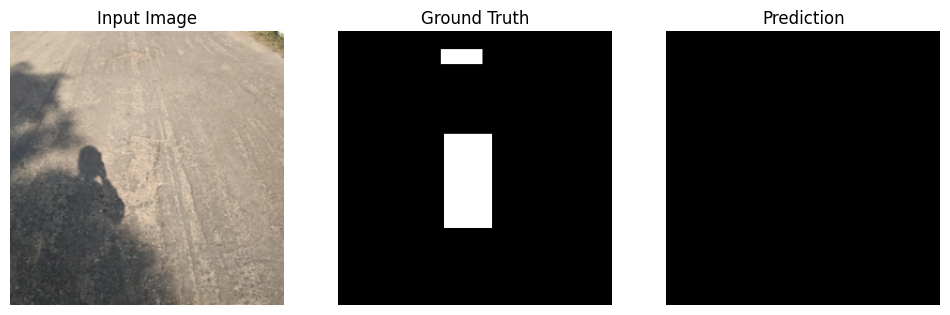

In [74]:
image, mask = train_dataset[0]

prediction = predict_full_image(image)

visualize(image, mask, prediction)

In [75]:
import os

save_dir = "outputs"
os.makedirs(save_dir, exist_ok=True)

def save_prediction(image, prediction, index):
    image_np = image.permute(1,2,0).cpu().numpy()
    image_np = (image_np * 0.5) + 0.5
    image_np = np.clip(image_np, 0, 1)

    pred_np = prediction.numpy()

    plt.imsave(f"{save_dir}/image_{index}.png", image_np)
    plt.imsave(f"{save_dir}/pred_{index}.png", pred_np, cmap='gray')

In [76]:
for i in range(10):
    image, mask = val_dataset[i]
    prediction = predict_full_image(image)

    save_prediction(image, prediction, i)

print("Predictions saved in outputs/")

NameError: name 'val_dataset' is not defined

In [77]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

def compute_confusion_matrix(dataset, num_samples=20):
    all_preds = []
    all_labels = []

    for i in range(num_samples):
        image, mask = dataset[i]
        prediction = predict_full_image(image)

        all_preds.extend(prediction.flatten().numpy())
        all_labels.extend(mask.flatten().numpy())

    cm = confusion_matrix(all_labels, all_preds)
    return cm

In [78]:
cm = compute_confusion_matrix(val_dataset, num_samples=20)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Road','Pothole'],
            yticklabels=['Road','Pothole'])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Pixel-wise Confusion Matrix")
plt.show()

NameError: name 'val_dataset' is not defined

In [79]:
def compute_accuracy(cm):
    correct = np.trace(cm)
    total = np.sum(cm)
    return correct / total

accuracy = compute_accuracy(cm)
print("Pixel Accuracy:", accuracy)

NameError: name 'cm' is not defined